In [1]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, cost_func_vqe, cost_func_wrapper
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_circuit_lr2

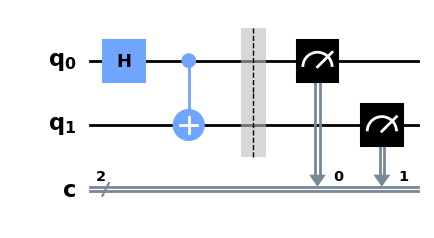

In [19]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt

# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
circuit.barrier()

# 2. Define measurement bases (for a simple Bell test, we'll use the Z basis for both qubits)
# In a more complex Bell test, you would rotate the measurement bases.
circuit.measure([0, 1], [0, 1])

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)


Histogram of Measurement Outcomes (1024 Events):
{'00': 480, '01': 0, '10': 0, '11': 544}


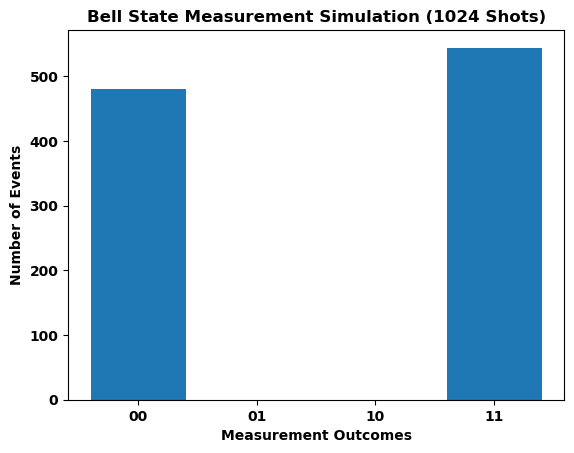

In [20]:
# 4. Ensure all four outcomes are present in the counts (even if zero)
all_outcomes = ['00', '01', '10', '11']
histogram_data = {outcome: counts.get(outcome, 0) for outcome in all_outcomes}

# 5. Print the histogram data
print("Histogram of Measurement Outcomes (1024 Events):")
print(histogram_data)

# Optional: Visualize the histogram
labels = histogram_data.keys()
values = histogram_data.values()

plt.bar(labels, values)
plt.xlabel("Measurement Outcomes")
plt.ylabel("Number of Events")
plt.title("Bell State Measurement Simulation (1024 Shots)")
plt.show()

[0. 0.]


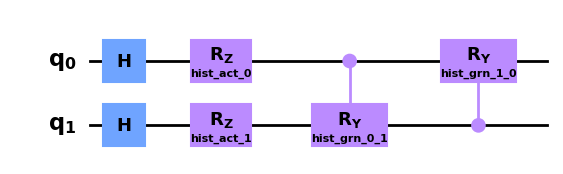

In [21]:
act_percentages = np.array([np.pi*1/12*0, np.pi*1/12*0])
print(act_percentages)
cirquit = create_grn_ansatz(2, "hist")
cirquit.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-480.+0.j,   -0.+0.j,   -0.+0.j, -544.+0.j])
Static Parameters: {Parameter(hist_act_0): 0.0, Parameter(hist_act_1): 0.0}
Variable Parameters: [Parameter(hist_grn_0_1), Parameter(hist_grn_1_0)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -1023.9999999999856
        x: [ 1.571e+00  1.231e+00]
      nit: 6
      jac: [-7.958e-05  3.411e-05]
     nfev: 24
     njev: 8
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


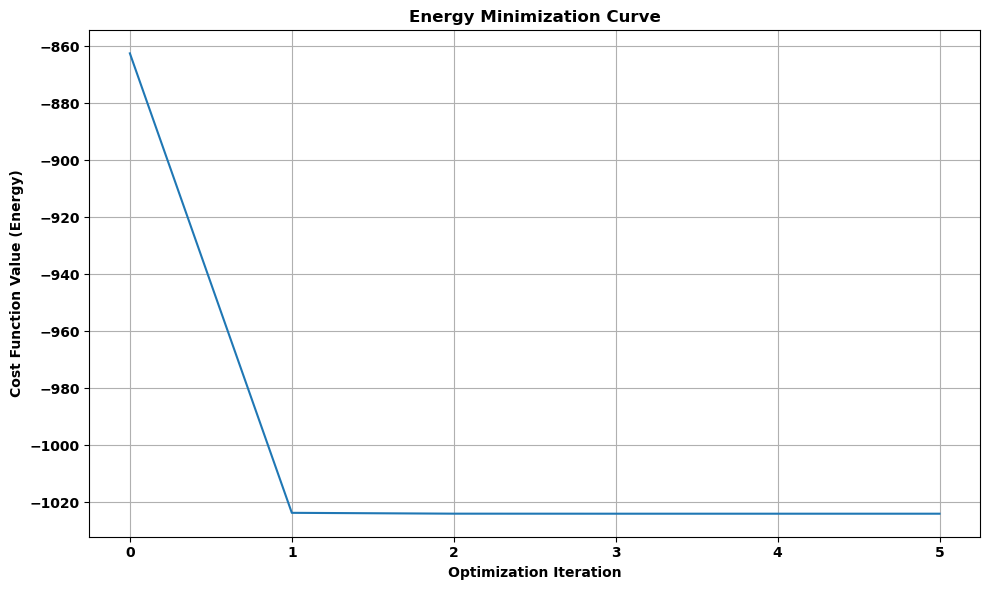

In [22]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

interaction_observable = create_interaction_observable_from_histogram(histogram_data, 2, min_ones = 0)
print("Interaction observable CT1 from histogram:", interaction_observable)

static_params, variable_params = create_parameter_dictionaries(cirquit, act_percentages)

print("Static Parameters:", static_params)
print("Variable Parameters:", variable_params)

estimator = StatevectorEstimator()

# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params = static_params.copy()  # Start with static parameters
all_params.update(dict(zip(variable_params, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params, cirquit, interaction_observable, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params, cirquit, interaction_observable, estimator, variable_params))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params, optimized_variable_parameters):
    all_params[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'00': 274, '11': 750}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:177: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


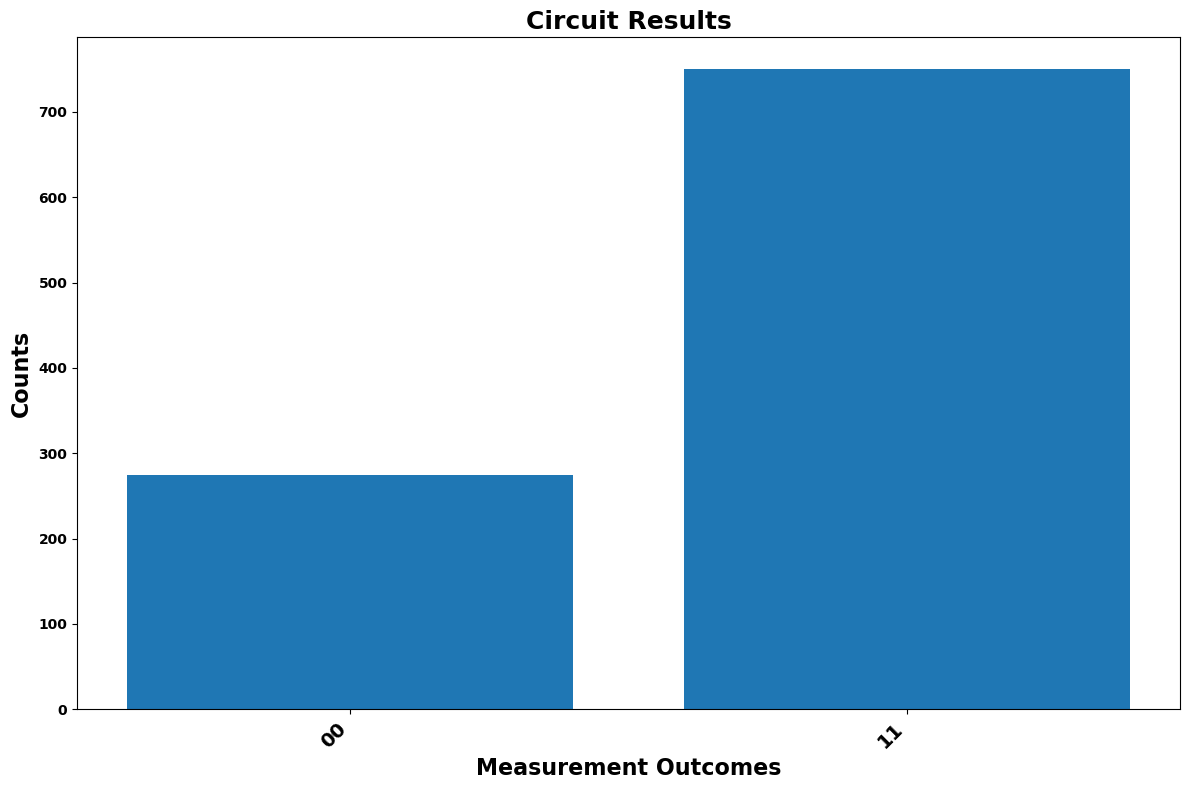

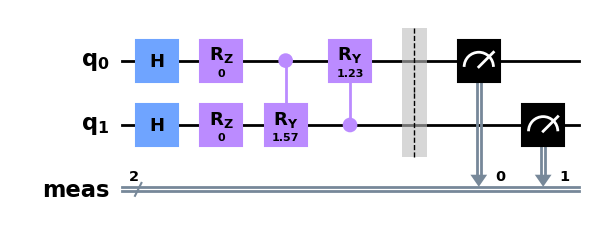

In [23]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirquit, all_params, shots=1024, title="Circuit Results")

bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

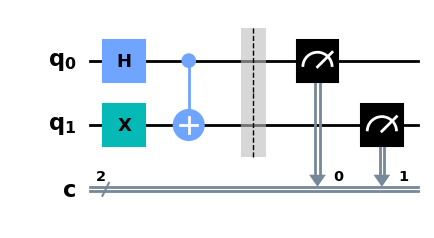

In [24]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt

# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
circuit = QuantumCircuit(2, 2)
circuit.x(1)
circuit.h(0)
circuit.cx(0, 1)
circuit.barrier()

# 2. Define measurement bases (for a simple Bell test, we'll use the Z basis for both qubits)
# In a more complex Bell test, you would rotate the measurement bases.
circuit.measure([0, 1], [0, 1])

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)


Histogram of Measurement Outcomes (1024 Events):
{'00': 0, '01': 503, '10': 521, '11': 0}


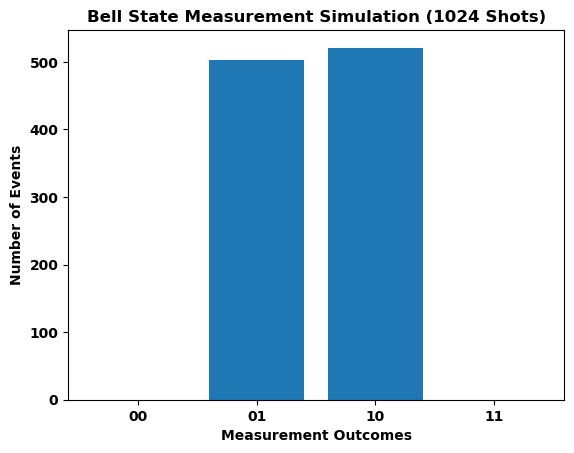

In [25]:


# 4. Ensure all four outcomes are present in the counts (even if zero)
all_outcomes = ['00', '01', '10', '11']
histogram_data = {outcome: counts.get(outcome, 0) for outcome in all_outcomes}

# 5. Print the histogram data
print("Histogram of Measurement Outcomes (1024 Events):")
print(histogram_data)

# Optional: Visualize the histogram
labels = histogram_data.keys()
values = histogram_data.values()

plt.bar(labels, values)
plt.xlabel("Measurement Outcomes")
plt.ylabel("Number of Events")
plt.title("Bell State Measurement Simulation (1024 Shots)")
plt.show()

[0. 0.]


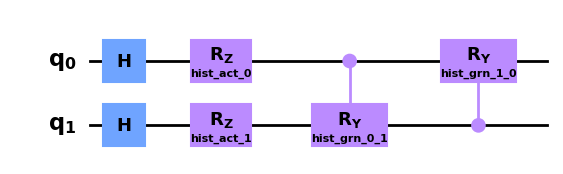

In [26]:
act_percentages = np.array([np.pi*0, np.pi*0])
print(act_percentages)
cirquit = create_grn_ansatz(2, "hist")
cirquit.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['IZ', 'ZI', 'ZZ'],
              coeffs=[-503.+0.j, -521.+0.j,   -0.+0.j])
Static Parameters: {Parameter(hist_act_0): 0.0, Parameter(hist_act_1): 0.0}
Variable Parameters: [Parameter(hist_grn_0_1), Parameter(hist_grn_1_0)]
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -260.4999999999998
        x: [-1.571e+00 -1.047e-07]
      nit: 11
      jac: [-5.684e-06 -5.684e-06]
     nfev: 36
     njev: 12
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


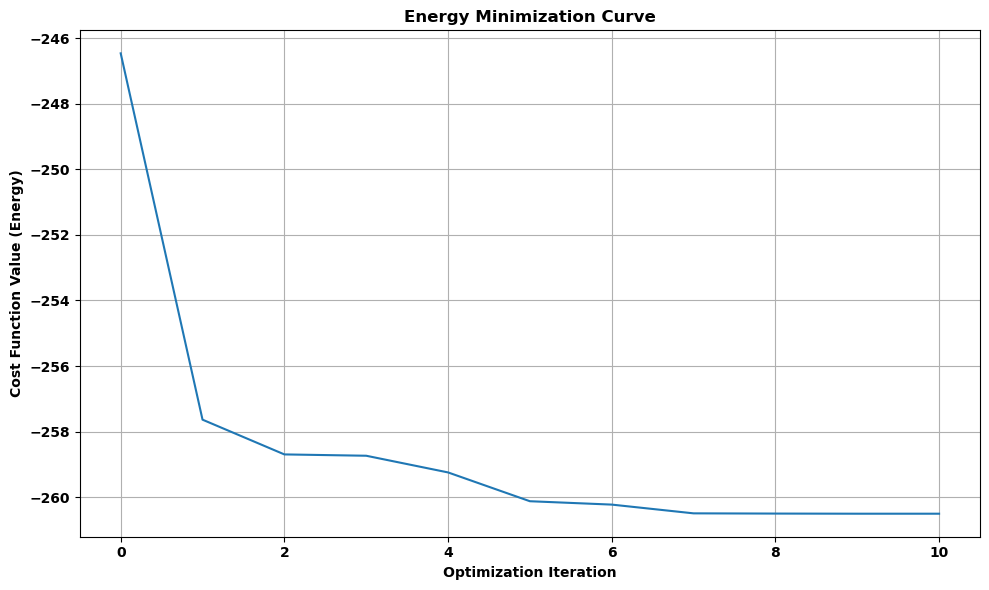

In [27]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

interaction_observable = create_interaction_observable_from_histogram(histogram_data, 2, min_ones = 1)
print("Interaction observable CT1 from histogram:", interaction_observable)

static_params, variable_params = create_parameter_dictionaries(cirquit, act_percentages)

print("Static Parameters:", static_params)
print("Variable Parameters:", variable_params)

estimator = StatevectorEstimator()

# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params = static_params.copy()  # Start with static parameters
all_params.update(dict(zip(variable_params, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params, cirquit, interaction_observable, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params, cirquit, interaction_observable, estimator, variable_params))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params, optimized_variable_parameters):
    all_params[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'10': 268, '01': 515, '00': 241}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:177: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


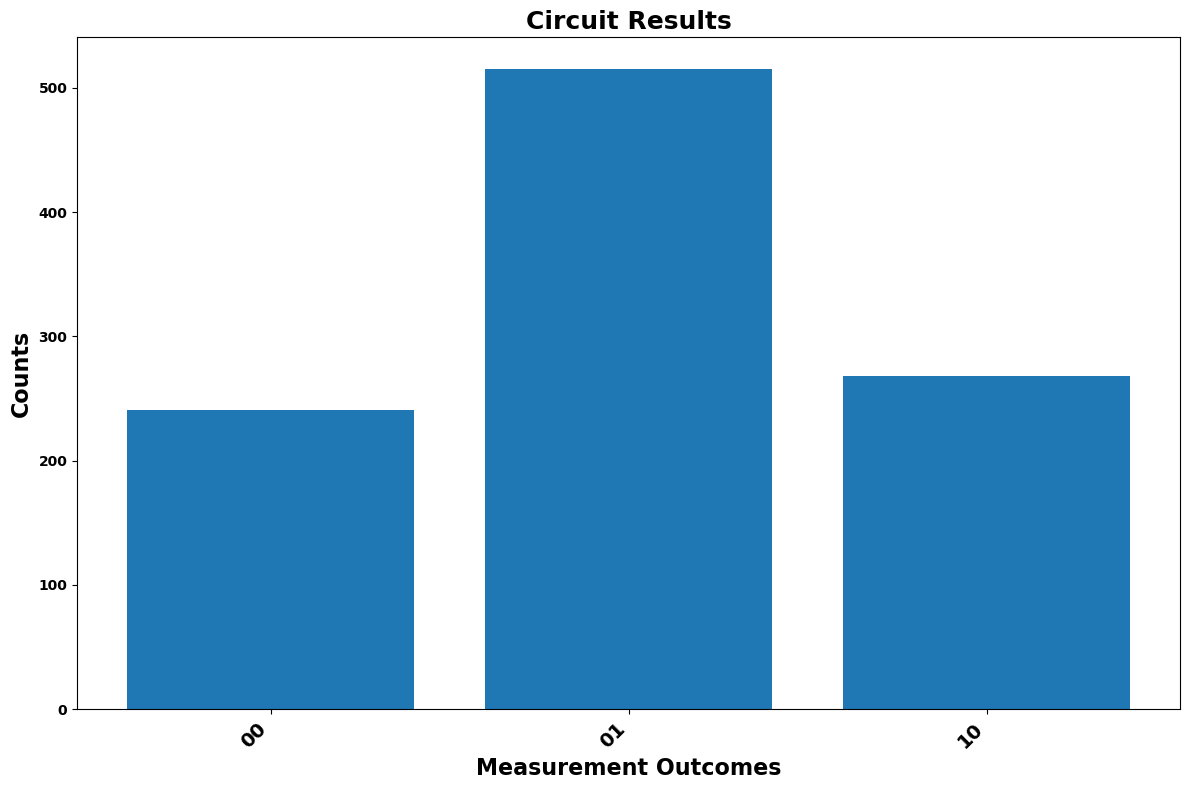

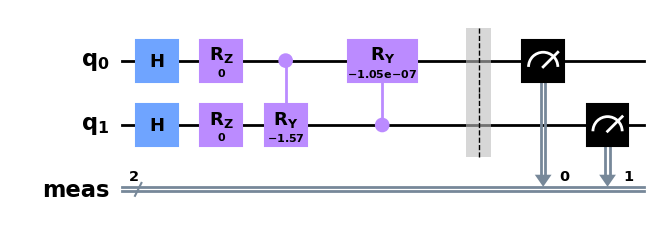

In [28]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirquit, all_params, shots=1024, title="Circuit Results")

bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

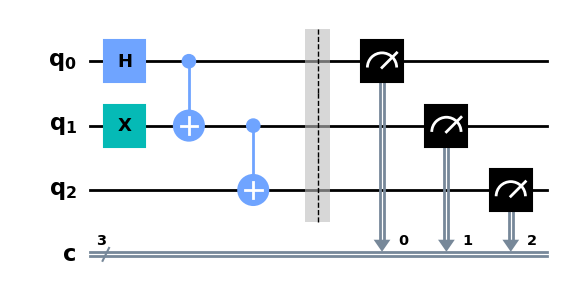

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt

# 1. Create the 3-qubit GHZ-like state
# |ψ⟩ = (|000⟩ + |111⟩)/√2
circuit = QuantumCircuit(3, 3) # Initialize with 3 qubits and 3 classical bits

circuit.h(0)
circuit.x(1)
#circuit.x(2)
circuit.cx(0, 1)
circuit.cx(1, 2)
circuit.cx(2, 0)

circuit.barrier()

# 2. Measure all three qubits
circuit.measure([0, 1, 2], [0, 1, 2])

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)


Histogram of Measurement Outcomes (1024 Events):
{'000': 0, '001': 502, '010': 0, '011': 0, '100': 0, '101': 0, '110': 522, '111': 0}


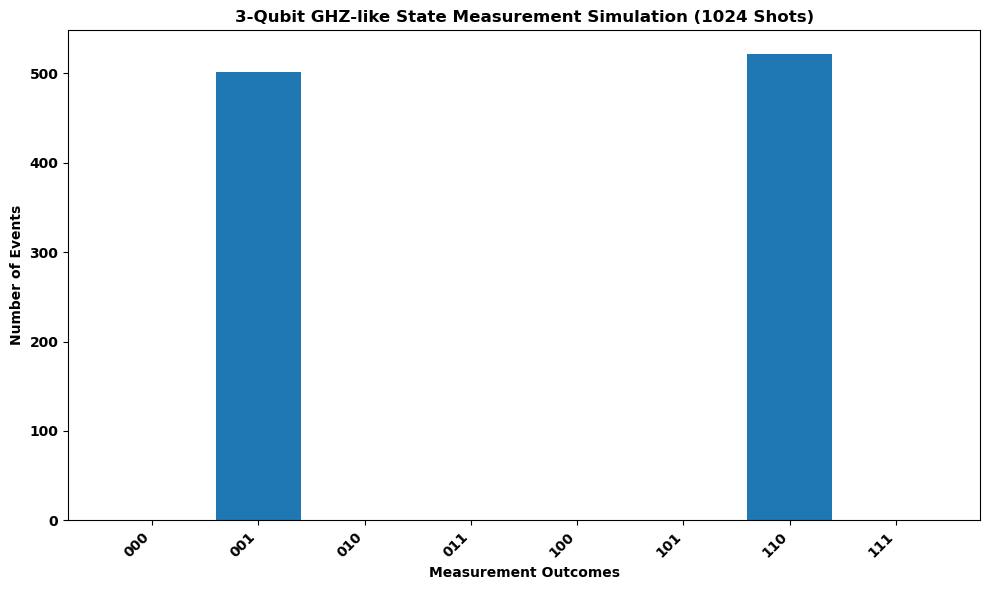

In [71]:

# 4. Ensure all eight possible outcomes are present in the counts (even if zero)
# For 3 qubits, the outcomes range from '000' to '111'
all_outcomes = [format(i, '03b') for i in range(2**3)] # Generates '000', '001', ..., '111'
histogram_data = {outcome: counts.get(outcome, 0) for outcome in all_outcomes}

# 5. Print the histogram data
print("Histogram of Measurement Outcomes (1024 Events):")
print(histogram_data)

# 6. Plot the Quantum Circuit
# Using circuit.draw(output="mpl") for Matplotlib output as requested
circuit.draw(output="mpl", style="clifford", fold=40)
plt.show() # Ensure the plot is displayed

# 7. Visualize the histogram
labels = histogram_data.keys()
values = histogram_data.values()

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
plt.bar(labels, values)
plt.xlabel("Measurement Outcomes")
plt.ylabel("Number of Events")
plt.title("3-Qubit GHZ-like State Measurement Simulation (1024 Shots)")
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

[0. 0. 0.]


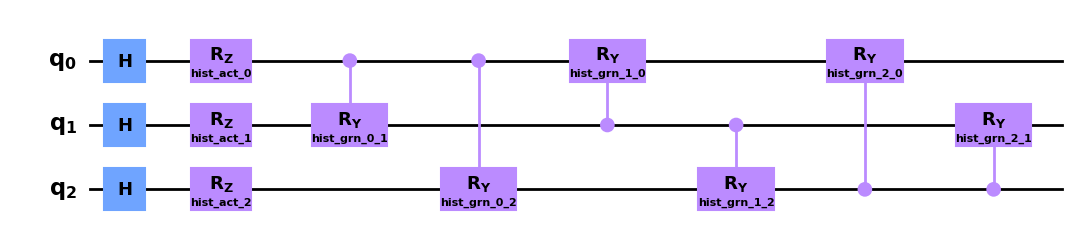

In [75]:
act_percentages = np.array([np.pi*2/3*0, np.pi*2/3*0, np.pi*2/3*0])
print(act_percentages)
cirquit = create_grn_ansatz(3, "hist")
cirquit.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['IZZ', 'ZIZ', 'ZZI', 'ZZZ'],
              coeffs=[  -0.+0.j,   -0.+0.j, -522.+0.j,   -0.+0.j])
Static Parameters: {Parameter(hist_act_0): 0.0, Parameter(hist_act_1): 0.0, Parameter(hist_act_2): 0.0}
Variable Parameters: [Parameter(hist_grn_0_1), Parameter(hist_grn_0_2), Parameter(hist_grn_1_0), Parameter(hist_grn_1_2), Parameter(hist_grn_2_0), Parameter(hist_grn_2_1)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -521.9999999997724
        x: [ 7.436e-02  2.183e-06 -7.441e-02  1.571e+00  1.025e-06
             1.196e+00]
      nit: 11
      jac: [-1.251e-04  1.933e-04 -1.251e-04 -1.137e-05  0.000e+00
            -2.274e-05]
     nfev: 98
     njev: 14
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>


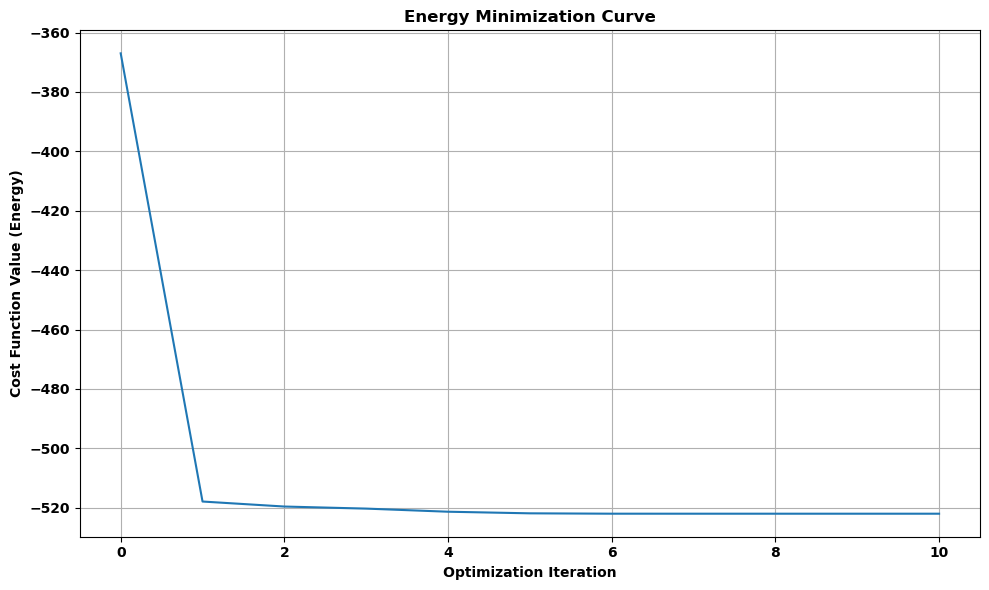

In [80]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

interaction_observable = create_interaction_observable_from_histogram(histogram_data, 3, min_ones = 2)
print("Interaction observable CT1 from histogram:", interaction_observable)

static_params, variable_params = create_parameter_dictionaries(cirquit, act_percentages)

print("Static Parameters:", static_params)
print("Variable Parameters:", variable_params)

estimator = StatevectorEstimator()

# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params = static_params.copy()  # Start with static parameters
all_params.update(dict(zip(variable_params, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params, cirquit, interaction_observable, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params, cirquit, interaction_observable, estimator, variable_params))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params, optimized_variable_parameters):
    all_params[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'001': 116, '111': 358, '110': 426, '000': 124}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:177: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


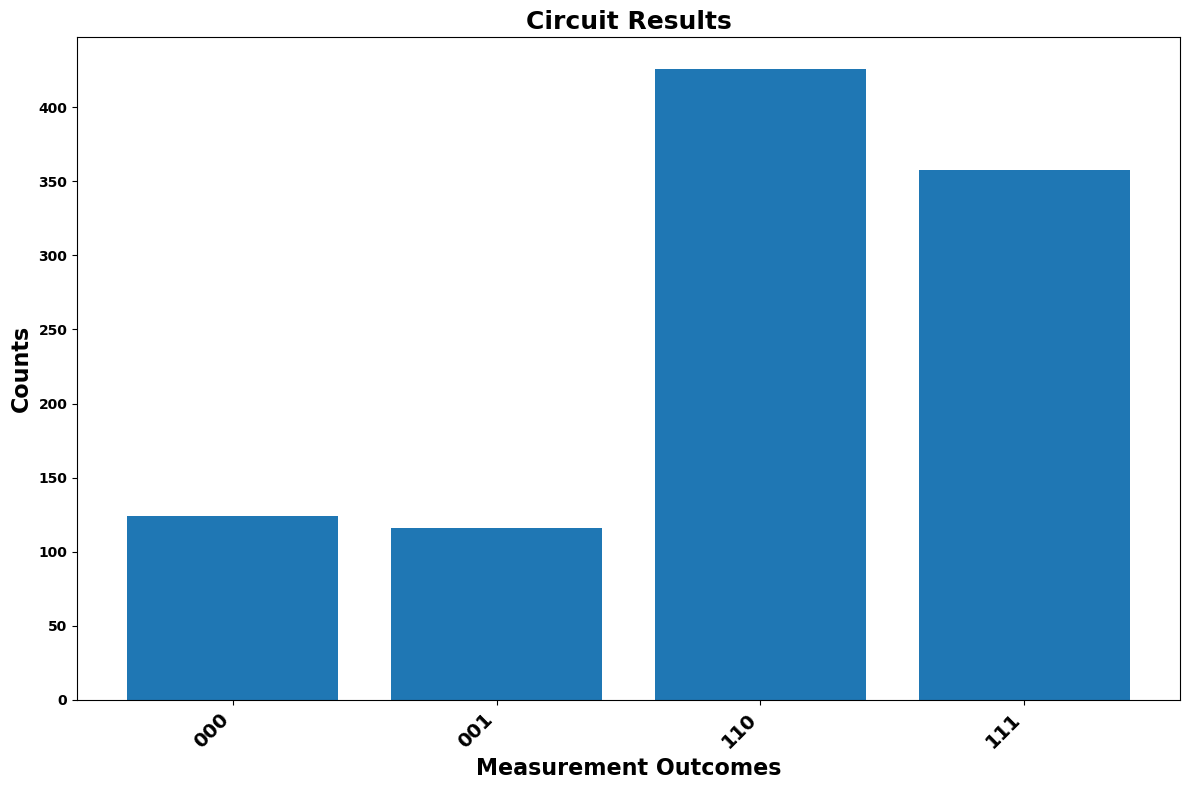

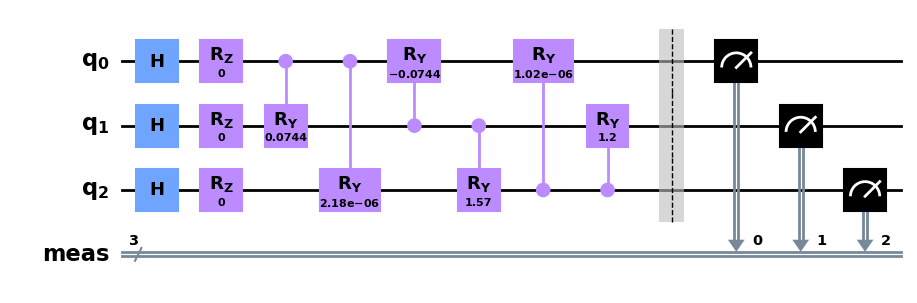

In [81]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirquit, all_params, shots=1024, title="Circuit Results")

bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot